# PRIMER EXAMEN DEL MINICURSO DE PYTHON

MAGALY BENAVIDES SANTIAGO

PRIMERO IMPORTAREMOS LAS PAQUETERIAS QUE VAMOS A USAR EN EL DOCUMENTO COMPLETO, SOLO IMPORTAMOS UNA SOLA VEZ. 

In [95]:
# INSTALAMOS PAQUETERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pymannkendall as mk


# EJERCICIO 1

Estamos en normalizacón de min-max, que transforma todos los datos al intervalo [0,1]

Primero implementaremos una función que estadarice un vector X usando la fórmula min-max

In [203]:
#Hacemos un arreglo de datos para operar vectorialmente usando la definición 
def calcular_idn(X):
    X=np.array(X)
#Obtenemos los valores mínimos y maximos 
    xmin=np.min(X)
    xmax =np.max(X)
#Fórmula de estandarizacion para obtener z
    Z= (X- xmin) / (xmax-xmin)
#Calculamos la varianza que es la definición de IDN (que es el promedio)
    z_barra= np.mean(Z)
#Ahora sí calculamos en indice de dispersión
    n = len(Z) #cuenta cuantos hay
    idn = (1/n)* np.sum((Z-z_barra)**2) #aplicamos la formula
# Nos da el valor estadarizado y el valor final de IDN
    return Z, idn

Ahora implementaremos los datos de prueba 

In [4]:
X_p= [12.4, 8.1, 15.7, 9.3, 14.8, 10.2, 11.6]

In [6]:
Z_resul, idn_resul= calcular_idn(X_p) # muestra la función  en dos variables y guarda la respuesta
#Imprimimos los resultados
print('El vector estadarizado es: ')
print(Z_resul)
print (f'\nvalor de IDN(X):{idn_resul: .6f}') #indica la cantidad de decimales que quiero que tenga

El vector estadarizado es: 
[0.56578947 0.         1.         0.15789474 0.88157895 0.27631579
 0.46052632]

valor de IDN(X): 0.116428


Compararemos el valor de IDN(X) con la varianza normalizada (np.var()), coinciden los valores 

In [8]:
varianza_np= np.var(Z_resul)
varianza_np

0.11642828876703037

In [9]:
print(f'Coincide los valores exactamente?: {np.isclose(idn_resul, varianza_np)}') #compara si son iguales ignorando variaciones

Coincide los valores exactamente?: True


# EJERCICIO 2 

El tema es graficas de superfice usando mallas

Nos piden visualizar la función en términos de z= f(x,y) en su dominio, entonces de la ecuación  que nos dan despejaremos z

Quitaremos la tangente con su función inversa, quitamos el denominador y el logaritmo, por lo que queda 
Z= np.exp(np.exp(np.cos(X+Y))-2 * np.arctan(np.sin(X+Y)))

<function matplotlib.pyplot.show(close=None, block=None)>

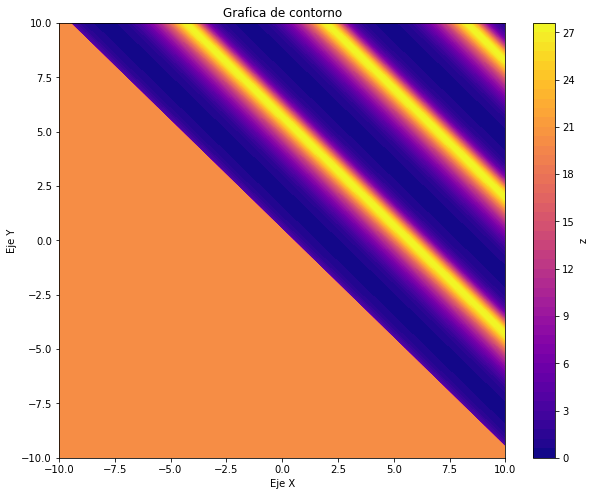

In [12]:
#Ahora graficaremos la malla, definiendo en valor de x y y, usando su dominio descrito
X= np.linspace(-10,10,500)
Y= np.linspace(-10,10,500)
#Creamos la malla en la que trabajaremos
X,Y = np.meshgrid(X,Y) # toma dos vectores y genera matrices que representan coordenadas de la cuadrícula 
#sabemos que z es:
Z= np.exp(np.exp(np.cos(X+Y))-2 * np.arctan(np.sin(X+Y)))
# Aplicamos condiciones inciales 
Z= np.where((X + Y)<=0.5,20,Z) # nos da la condición, el valor si se cumple y en caso de que no se cumpla se andqueda con su valor original
#Hacemos el grafico que lo representará 
fig = plt.figure(figsize=(10,8)) #donde estará la gráfica
cp=plt.contourf(X,Y,Z, levels=50, cmap='plasma') #hace la gráfica de contorno
plt.colorbar(cp, label='z')#ayuda a observar los min y max de la funcion z en el dominio(-10,10)
plt.title('Grafica de contorno')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.show


# EJERCICIO 3 

Utilice los datos de los nacimientos por estado del 2020 al 2022 del repositorio en Github y realice lo siguiente:

a) Obtenga un Dataframe que tenga como columnas el número de nacimientos de mujeres, el número de nacimientos de hombres
y el número total de nacimientos por año durante el 2020 al 2022. Obtenga una gráfica de cada categoría.

b) Agregue a los datos de nacimientos del 2020 la columna de población por estado y la tasa de nacimientos por cada mil
habitantes. Gráfique la tasa de nacimientos por estado.

In [13]:
# ANEXAMOS LA RUTA DE LOS ARCHIVOS
naci20='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2020.csv'
naci21='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2021.csv'
naci22='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2022.csv'

In [14]:
# LEEMOS LOS DATAFRAME
naci2020=pd.read_csv(naci20)
naci2021=pd.read_csv(naci21)
naci2022=pd.read_csv(naci22)

In [15]:
#AGREGAMOS UNA NUEVA COLUMNA
naci2020['Año']=2020
naci2021['Año']=2021
naci2022['Año']=2022

In [16]:
# UNIMOS TODAS LAS BASES DE DATOS EN UN SOLO DATAFRAME USANDO CONCAT
df_nacimientos=pd.concat([naci2020, naci2021, naci2022], ignore_index=True)
df_nacimientos.head()

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total,Año
0,Aguascalientes,AG,Noreste,9966,10404,0,20370,2020
1,Baja California,BC,Noroeste,23539,24406,0,47945,2020
2,Baja California Sur,BS,Noroeste,4982,5099,0,10081,2020
3,Campeche,CM,Sureste,5275,5454,0,10729,2020
4,Coahuila de Zaragoza,CO,Noreste,22594,23221,0,45815,2020


In [17]:
# AGRUPAMOS POR AÑO.
total_año=df_nacimientos.groupby('Año')['Hombres','Mujeres'].sum()
total_año['Total/año']= total_año ['Hombres']+ total_año ['Mujeres']
print (total_año)

      Hombres  Mujeres  Total/año
Año                              
2020   827072   798452    1625524
2021   965088   938302    1903390
2022   956137   924579    1880716


C:\Users\deade\AppData\Local\Temp\ipykernel_30752\2026513499.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  total_año=df_nacimientos.groupby('Año')['Hombres','Mujeres'].sum()


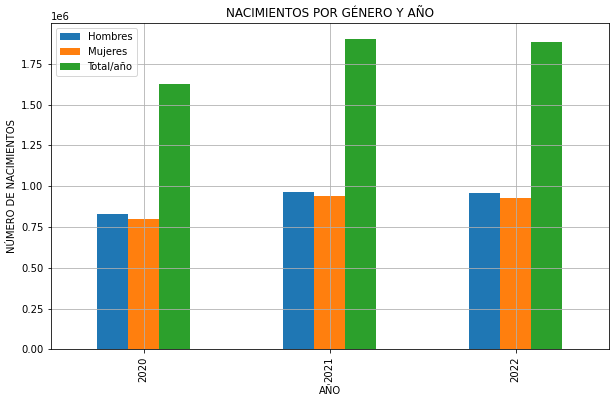

In [18]:
# GRAFICAMOS POR CATEGORIA
total_año.plot(kind='bar', figsize=(10,6)) #bar nos da barra verticales
plt.xlabel("AÑO")
plt.ylabel("NÚMERO DE NACIMIENTOS")
plt.title("NACIMIENTOS POR GÉNERO Y AÑO")
plt.xticks()
plt.grid()
plt.show()

In [19]:
#NOS FALTA AGREGAR EL DATAFRAME DE POBLACIÓN
ruta='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/poblacion.csv'
df_pobla = pd.read_csv(ruta)
df_pobla.head()

,Estado,Regiones,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020
0,Aguascalientes,Noreste,350218,369441,456533,487752,576638,608358,696683,728924
1,Baja California,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431
2,Baja California Sur,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568
3,Campeche,Sureste,268772,266413,344334,346355,407721,414720,456939,471424
4,Coahuila de Zaragoza,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102


In [20]:
#AGREGAMOS LA POBLACIÓN TOTAL DEL AÑO EN QUE OCURRE (2020)
df_pobla['Total_2020']=df_pobla['M_2020']+ df_pobla['H_2020']
df_pobla.head()

,Estado,Regiones,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020,Total_2020
0,Aguascalientes,Noreste,350218,369441,456533,487752,576638,608358,696683,728924,1425607
1,Baja California,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431,3769020
2,Baja California Sur,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568,798447
3,Campeche,Sureste,268772,266413,344334,346355,407721,414720,456939,471424,928363
4,Coahuila de Zaragoza,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102,3146771


In [21]:
#UNIMOS LOS NACIMIENTOS CON LA POBLACIÓN USANDO EL NOMBRE DE ESTADO
df_2020= pd.merge (naci2020, df_pobla, on='Estado')
df_2020.head()

,Estado,Abreviatura,Regiones_x,Mujeres,Hombres,No_esp,Total,Año,Regiones_y,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020,Total_2020
0,Aguascalientes,AG,Noreste,9966,10404,0,20370,2020,Noreste,350218,369441,456533,487752,576638,608358,696683,728924,1425607
1,Baja California,BC,Noroeste,23539,24406,0,47945,2020,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431,3769020
2,Baja California Sur,BS,Noroeste,4982,5099,0,10081,2020,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568,798447
3,Campeche,CM,Sureste,5275,5454,0,10729,2020,Sureste,268772,266413,344334,346355,407721,414720,456939,471424,928363
4,Coahuila de Zaragoza,CO,Noreste,22594,23221,0,45815,2020,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102,3146771


In [22]:
#CALCULAMOS LA TASA 
df_2020['Tasa']=(df_2020['Total']/ df_2020['Total_2020'])*1000
df_2020.head()

,Estado,Abreviatura,Regiones_x,Mujeres,Hombres,No_esp,Total,Año,Regiones_y,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020,Total_2020,Tasa
0,Aguascalientes,AG,Noreste,9966,10404,0,20370,2020,Noreste,350218,369441,456533,487752,576638,608358,696683,728924,1425607,14.288650
1,Baja California,BC,Noroeste,23539,24406,0,47945,2020,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431,3769020,12.720813
2,Baja California Sur,BS,Noroeste,4982,5099,0,10081,2020,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568,798447,12.625760
3,Campeche,CM,Sureste,5275,5454,0,10729,2020,Sureste,268772,266413,344334,346355,407721,414720,456939,471424,928363,11.556902
4,Coahuila de Zaragoza,CO,Noreste,22594,23221,0,45815,2020,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102,3146771,14.559369


In [24]:
# Ordenar de mayor a menor, hace que el estado con más nacimientos quede arriba
df_2020 = df_2020.sort_values(by='Tasa')

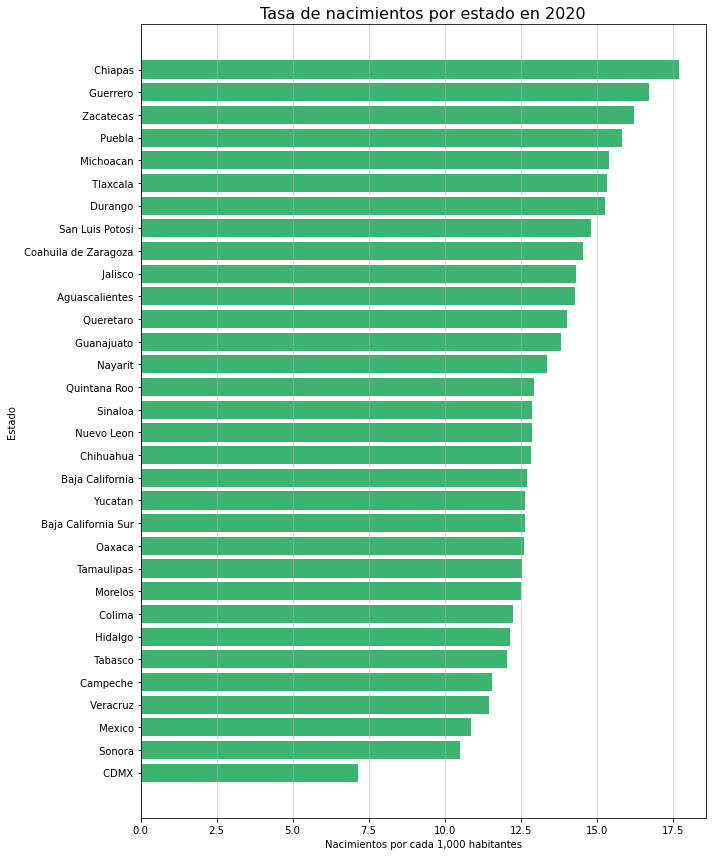

In [25]:
#GRAFICAMOS TASA DE NACIMIENTOS
plt.figure(figsize=(10, 12))
plt.barh(df_2020['Estado'], df_2020['Tasa'], color='mediumseagreen')
plt.title('Tasa de nacimientos por estado en 2020', fontsize=16)
plt.xlabel('Nacimientos por cada 1,000 habitantes')
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.6) 
plt.tight_layout() 
plt.show()

# EJERCICIO 4

Guarde en un Dataframe los datos de los precios de las acciones de Tesla (tesla.csv en Github).

El retorno simple mide el cambio porcentual entre el precio de un activo financiero en dos momentos consecutivos. 
Es útil para analizar la variación de precios, por ejemplo, el precio de cierre diario de una acción. Dado un precio de 
cierre P_t en el tiempo t, el retorno simple se calcula...

a) Agregue la columna correspondiente a la serie de retornos simples (utilice la función .pct_change()) y elimine la primera fila del DataFrame.

b) Grafique la serie de tiempo de los retornos simples y obtenga:

El retorno simple más alto,
El retorno simple más bajo,
Las fechas en que ocurrieron.
c) Obtenga el histograma de frecuencia de la serie de retornos simples.
¿Estos se distribuyen normalmente? Justifique su respuesta calculando el coeficiente de asimetría, kurtosis y haciendo la prueba de Shapiro–Wilk.

d) Genere las gráficas de caja por año de los precios de cierre.

In [70]:
# Primero generamos la ruta del dataframe
ruta = 'https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/TSLA.csv'
df = pd.read_csv(ruta, parse_dates = ['Date'], index_col=0) #se indexa la columna de date como índice principal
df.head()

,Open,High,Low,Close,Adj Close
Date,,,,,
2019-09-30,16.200001,16.265333,15.740667,16.058001,16.058001
2019-10-01,16.100000,16.396667,15.942000,16.312668,16.312668
2019-10-02,16.219334,16.309999,15.962000,16.208668,16.208668
2019-10-03,15.457333,15.632000,14.952000,15.535333,15.535333
2019-10-04,15.440667,15.652000,15.204667,15.428667,15.428667


In [71]:
#Agregamos una nueva columna, usamos close porque habla del precio de cierre
df['Retorno']= df['Close'].pct_change()
df.head()

,Open,High,Low,Close,Adj Close,Retorno
Date,,,,,,
2019-09-30,16.200001,16.265333,15.740667,16.058001,16.058001,NaN
2019-10-01,16.100000,16.396667,15.942000,16.312668,16.312668,0.015859
2019-10-02,16.219334,16.309999,15.962000,16.208668,16.208668,-0.006375
2019-10-03,15.457333,15.632000,14.952000,15.535333,15.535333,-0.041542
2019-10-04,15.440667,15.652000,15.204667,15.428667,15.428667,-0.006866


In [72]:
#Eliminamos la primer fila porque el retorno sale NaN, es decir que está vacío 
df.dropna()

,Open,High,Low,Close,Adj Close,Retorno
Date,,,,,,
2019-10-01,16.100000,16.396667,15.942000,16.312668,16.312668,0.015859
2019-10-02,16.219334,16.309999,15.962000,16.208668,16.208668,-0.006375
2019-10-03,15.457333,15.632000,14.952000,15.535333,15.535333,-0.041542
2019-10-04,15.440667,15.652000,15.204667,15.428667,15.428667,-0.006866
2019-10-07,15.320000,15.904000,15.236667,15.848000,15.848000,0.027179
...,...,...,...,...,...,...
2023-09-21,257.850006,260.859985,254.210007,255.699997,255.699997,-0.026239
2023-09-22,257.399994,257.790009,244.479996,244.880005,244.880005,-0.042315
2023-09-25,243.380005,247.100006,238.309998,246.990005,246.990005,0.008616


In [73]:
fecha_min = df['Retorno'].idxmax()
fecha_min

Timestamp('2020-02-03 00:00:00')

In [74]:
fecha_max = df['Retorno'].idxmin()
fecha_max

Timestamp('2020-09-08 00:00:00')

In [75]:
retorno_min = df["Retorno"].min()
retorno_max = df["Retorno"].max()

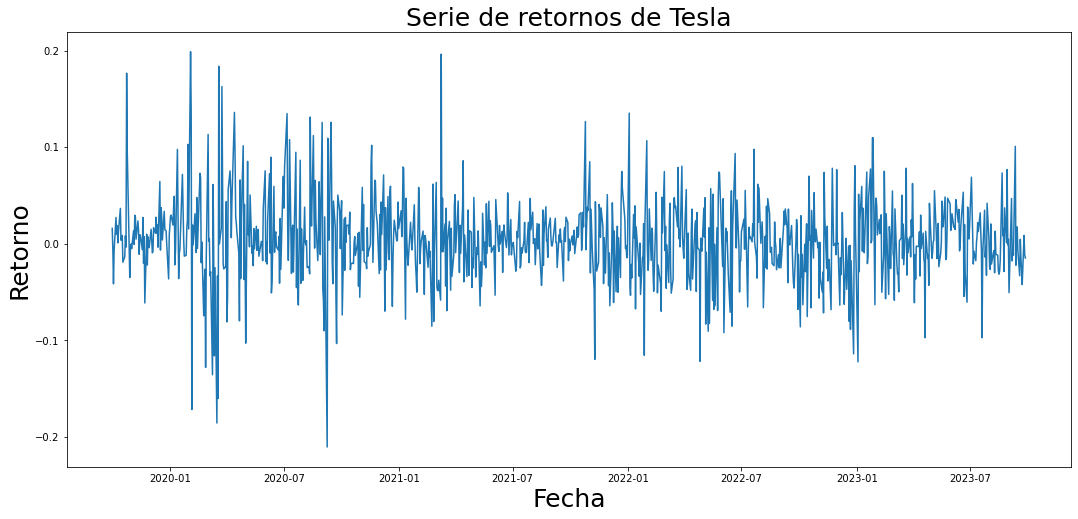

El retorno simple mas alto fue: -0.2106282385165198, fecha: 2020-02-03 00:00:00
El retorno simple mas bajo fue: 0.19894859586288027, fecha: 2020-09-08 00:00:00


In [76]:
#Ahora graficaremos los retornos 
plt.figure(figsize=(18,8)) # tamaño del gráfico 
plt.plot(df.index, df['Retorno']) #elegimos esos valores para ver como cambia la variable con el tiempo
plt.title('Serie de retornos de Tesla', fontsize = 25)
plt.xlabel('Fecha', fontsize = 25)
plt.ylabel('Retorno', fontsize = 25)
plt.show()
#El retorno simple más alto, El retorno simple más bajo, Las fechas en que ocurrieron. 
print(f'El retorno simple mas alto fue: {retorno_min}, fecha: {fecha_min}')
print(f'El retorno simple mas bajo fue: {retorno_max}, fecha: {fecha_max}')

c) Obtenga el histograma de frecuencia de la serie de retornos simples.

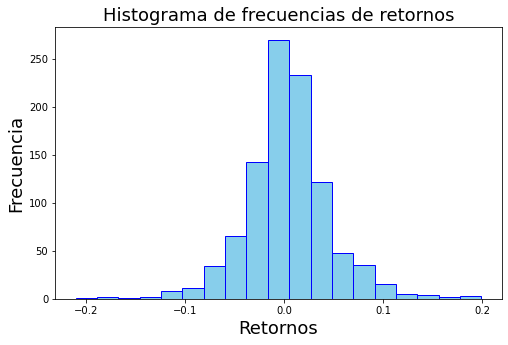

In [77]:
plt.figure(figsize=(8,5))
plt.hist(df['Retorno'], bins=19, 
         color='skyblue', edgecolor='blue')
plt.title('Histograma de frecuencias de retornos', fontsize = 18)
plt.xlabel('Retornos', fontsize = 18)
plt.ylabel('Frecuencia', fontsize = 18)
plt.show()

¿Estos se distribuyen normalmente? Justifique su respuesta calculando el coeficiente de asimetría, kurtosis
y haciendo la prueba de Shapiro–Wilk.

In [78]:
df['Retorno'].skew() #Coeficiente de asimetría de Fisher

0.12063001791360128

Este coeficiente nos permite calcular la asimetría de una distribucion.Dado que la muestra tiene distribución mayor a cero, podemos concluir que la asimetría es positiva. 

In [79]:
df['Retorno'].kurt() #Kurtosis

3.0222182399976165

La Kurtosisi nos define en qué grado las colas se distribuyen diferente a una distribucion normal. Dado que la muestra, tiene colas más largas, podemos conlcluir que tiene distribución  leptocurtica. 

In [56]:
from scipy.stats import shapiro

In [80]:
estadistico, p_value = shapiro(df['Retorno'].dropna()) #dropna filtra datos nulos
print(f'Estadístico = {estadistico:.3f}, p-value = {p_value:.10f}\n')

Estadístico = 0.961, p-value = 0.0000000000



La prueba Shapiro-Wilk nos permite evaluar si un conjunto de datos sigue una distribucion normal, esta prueba se basa en hipótesis nulas que afirman que la muestra proviene de una distribución normal, estonces podemos concluir que la muestra rechaza la hipótesis nula, debido a que "p" es mucho menor a 0.05, indica evidencia suficiente contra la normalidad 

d) Genere las gráficas de caja por año de los precios de cierre.

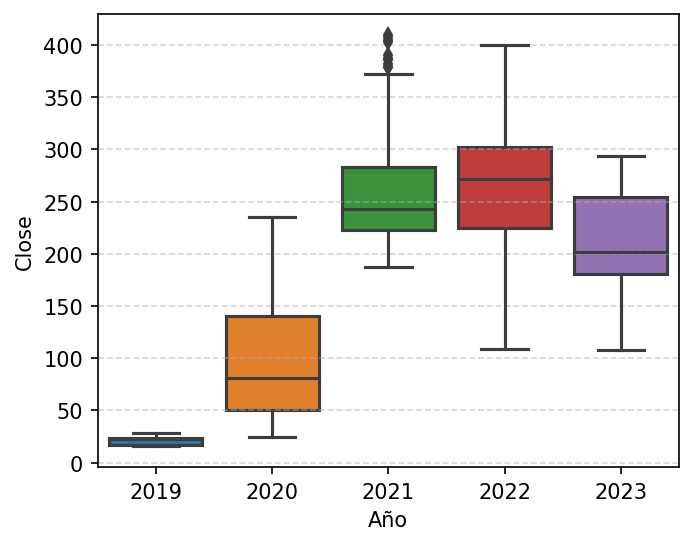

In [89]:
plt.figure(figsize=(5,4),dpi=150)
sns.boxplot(data=df, x='Año', y='Close') #seaborn lee el data y busca el año para graficar con valores de close
plt.grid(axis="y", linestyle='--', alpha=0.5) # añade cuadriculas al fondo 
plt.show()

# EJERCICIO 5

Guarde en un DataFrame los datos de los 6 contaminantes principales de la ciudad de Puebla a partir del año 2016 (contam_PUE_ugm3.csv en GitHub). A continuación, realice lo siguiente:

a) Obtenga las gráficas de series de tiempo de todos los contaminantes, los gráficos de caja, y calcule el número de datos atípicos de cada uno.

b) Realice una prueba de contraste de normalidad para los datos. Obtenga una matriz de correlación y un mapa de calor de los contaminantes utilizando el coeficiente de correlación apropiado.

c) Obtenga un DataFrame que muestre la correlación 2 a 2 entre los contaminantes.
Grafique 3 diagramas de dispersión** entre los contaminantes que presentan mayor correlación, ya sea positiva o negativa.

d) Aplique el test de Mann-Kendall a todos los contaminantes y obtenga una gráfica con la línea de tendencia de cada uno (en caso de que exista).

e) Compruebe la existencia de tendencia mediante el método ITA (Innovative Trend Analysis).

In [100]:
#Agregamos la ruta e indexamos la fecha
ruta_con='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/contam_PUE_ugm3.csv'
contam_pue = pd.read_csv(ruta_con, parse_dates = True, index_col=0)
contam_pue.head()

,O3,PM10,PM25,SO2,CO,NO2
Fecha,,,,,,
2016-01-01,0.028414,44.694444,28.097222,0.003244,1.763388,0.020635
2016-01-02,0.027376,31.527778,13.791667,0.003339,1.796858,0.022468
2016-01-03,0.032512,44.333333,20.430556,0.003551,1.845788,0.023123
2016-01-04,0.028332,24.990338,9.569444,0.003051,1.756417,0.020897
2016-01-05,0.026939,21.763889,10.638889,0.003296,1.782832,0.021215


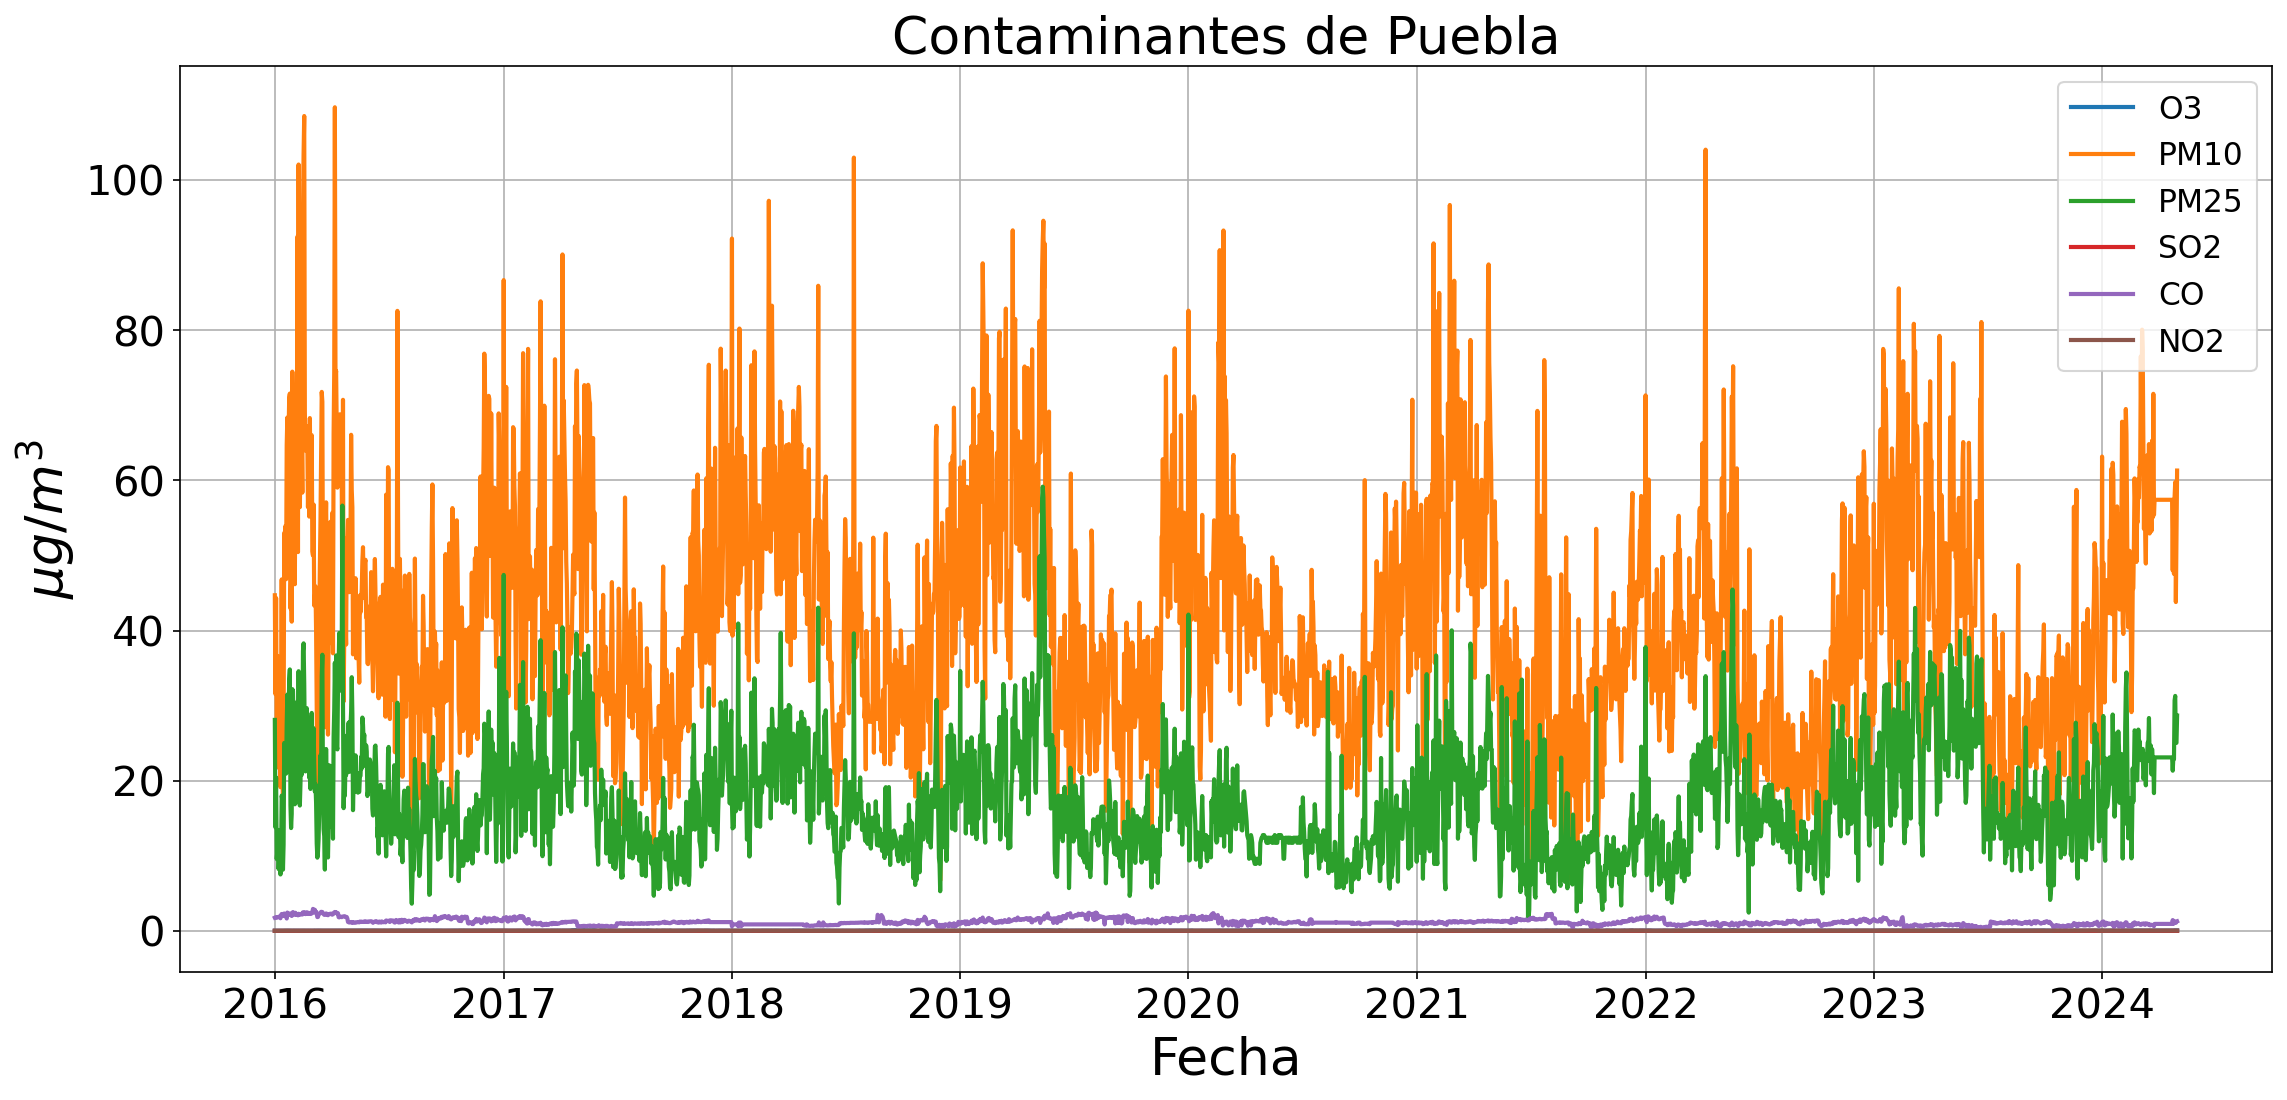

In [107]:
#Hacemos las series de tiempo
#selecionamos las columnas de los compuestos
compuestos=['O3', 'PM10', 'PM25', 'SO2', 'CO', 'NO2']
plt.figure(figsize=(18,8), dpi=150)
plt.plot(contam_pue.index,contam_pue[compuestos],lw=2)
plt.xlabel('Fecha', fontsize = 25)
plt.ylabel('$\mu g/m^3$',fontsize = 25)
plt.title('Contaminantes de Puebla', fontsize = 25)
plt.legend(compuestos, fontsize=15)
plt.tick_params(labelsize=20)
plt.grid(True)
plt.show()
#NOTAMOS QUE TODOS SE VEN AMONTONADOS Y NO LOGRAMOS APRECIARLOS, ENTONCES LOS HAREMOS DE MANERA INDIVIDUAL 

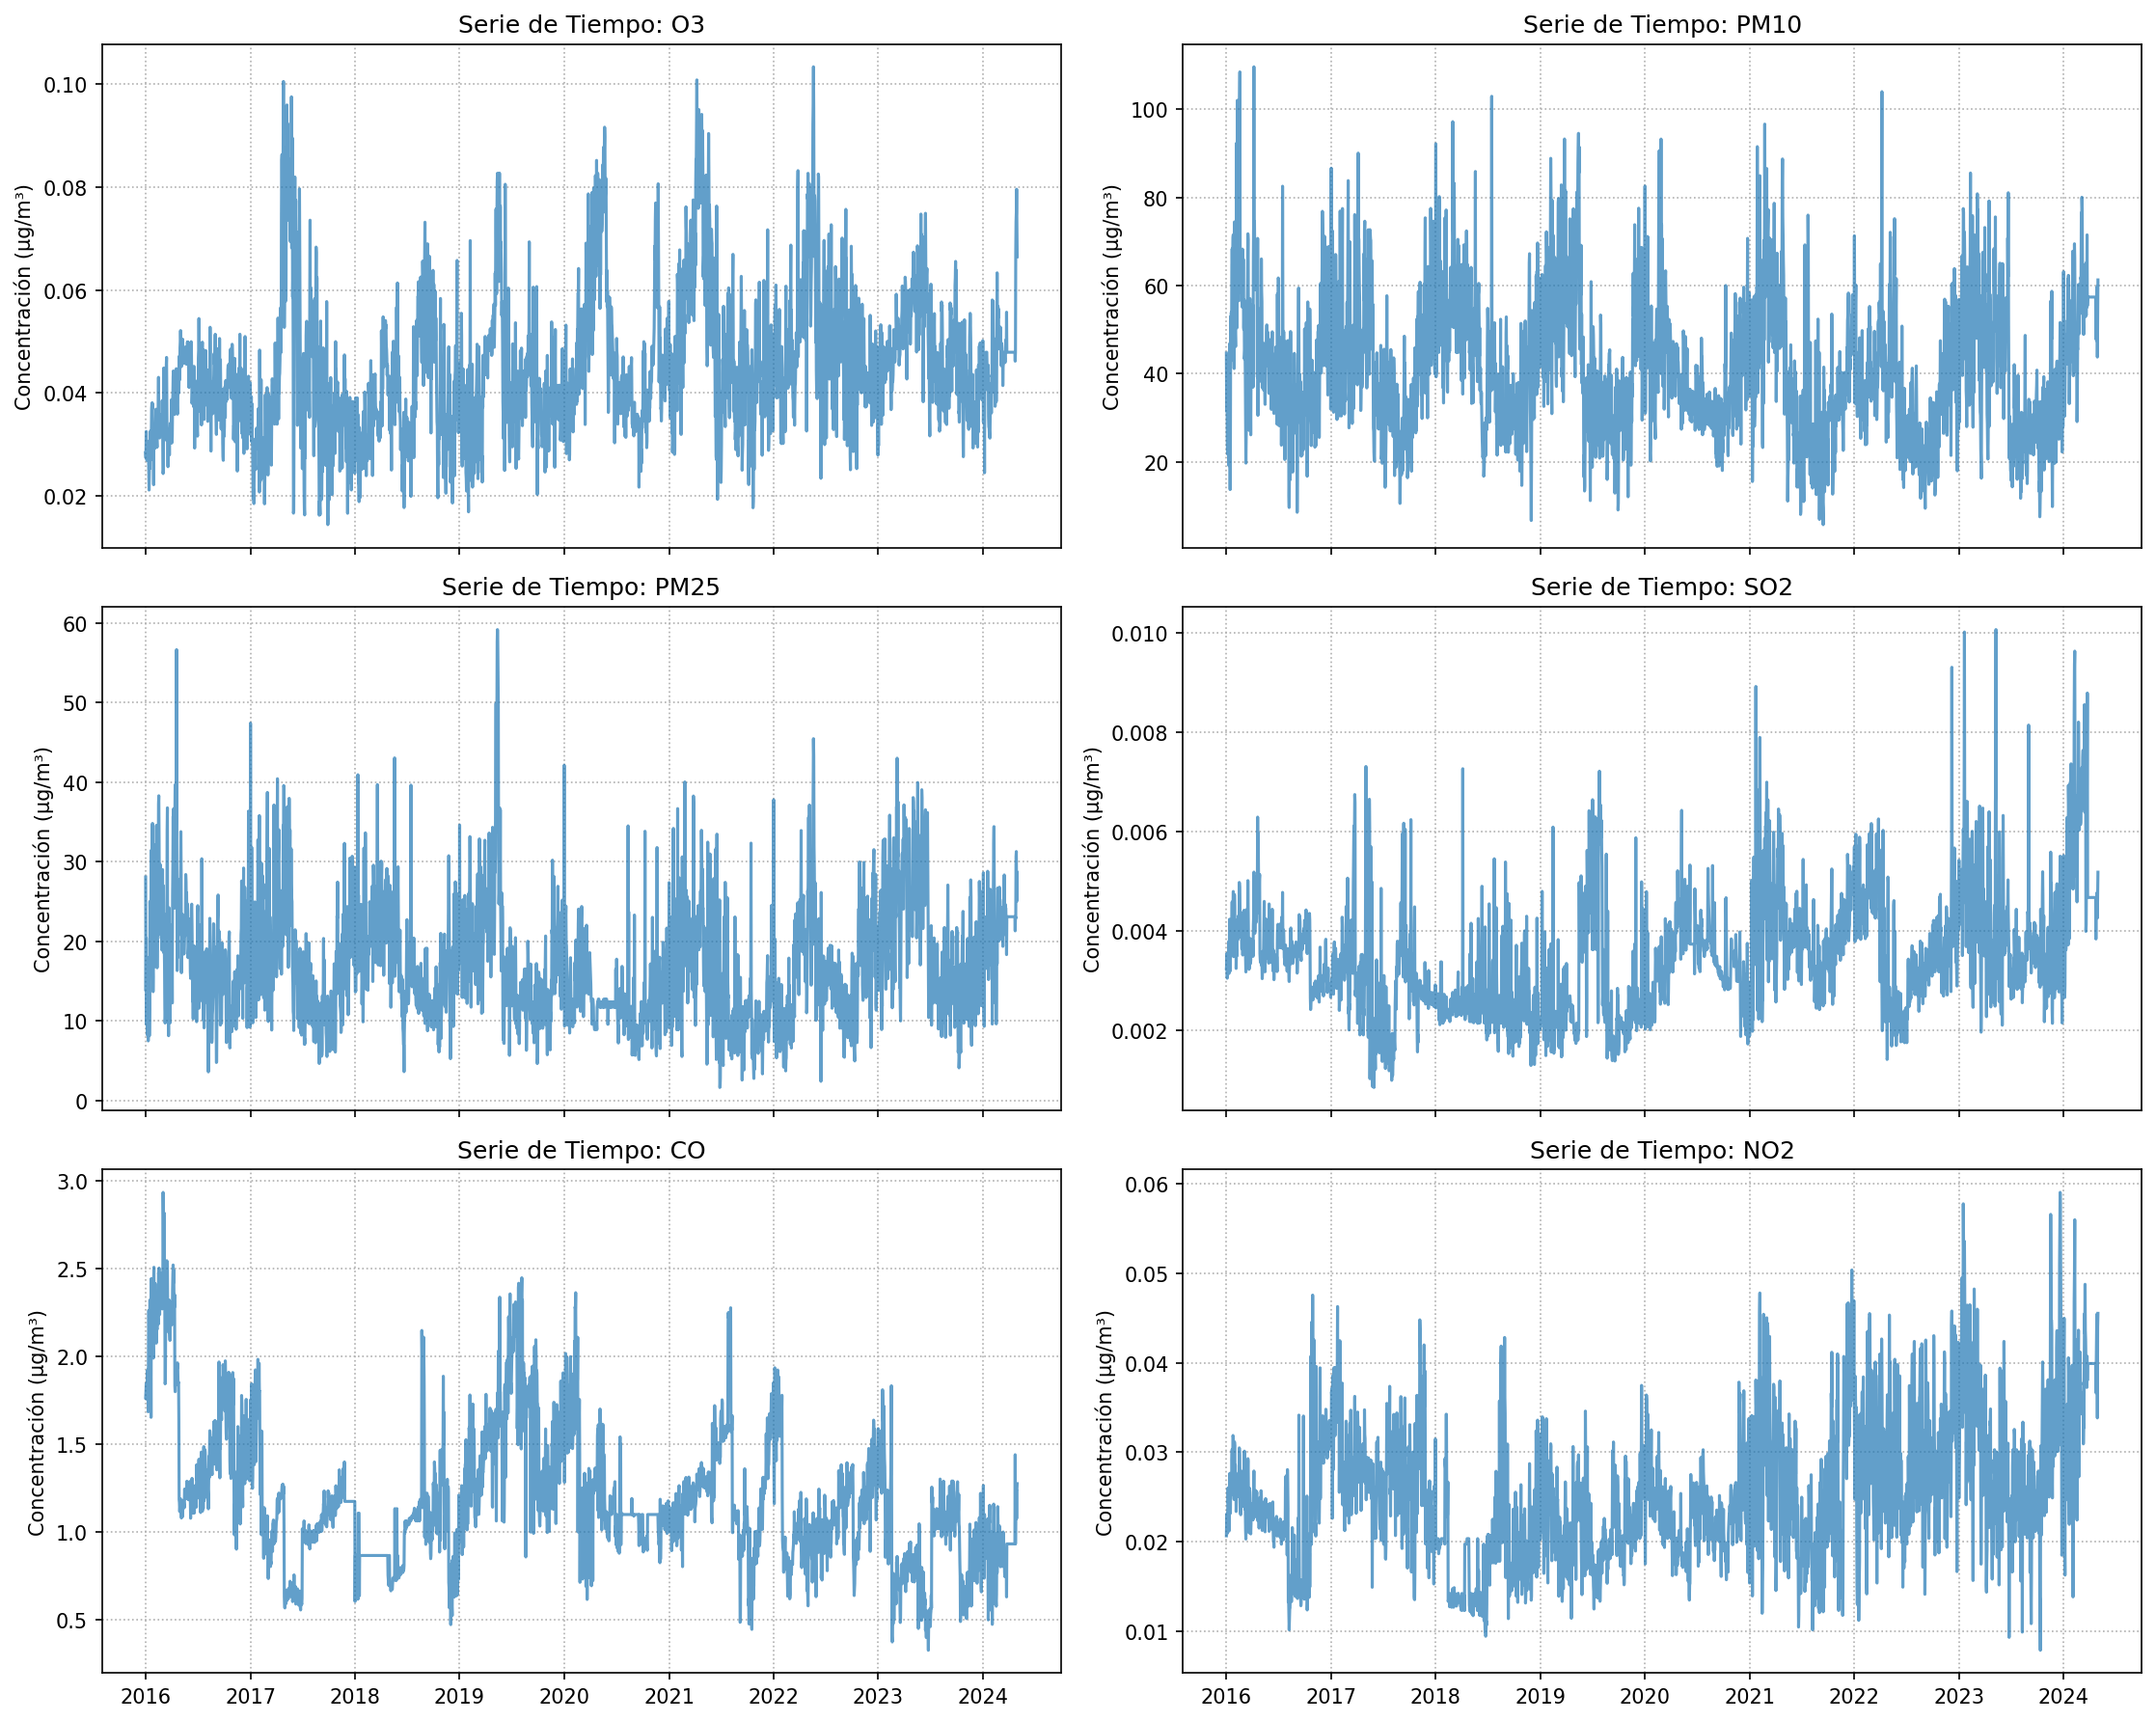

In [204]:
contaminantes=['O3', 'PM10', 'PM25', 'SO2', 'CO', 'NO2'] #share alinea los ejer y flatten itera sobre la cuadrícula 
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12), dpi=150, sharex=True)
axes= axes.flatten() #convierte la  tabla en una lista sencilla
for i, comp  in enumerate (contaminantes): # enumera el compuesto con su nombre
    axes[i].plot(contam_pue.index, contam_pue[comp], alpha=0.7)
    axes[i].set_title(f'Serie de Tiempo: {comp}')
    axes[i].set_ylabel('Concentración (µg/m³)')
    axes[i].grid(True, linestyle=':')
plt.tight_layout()
plt.show()


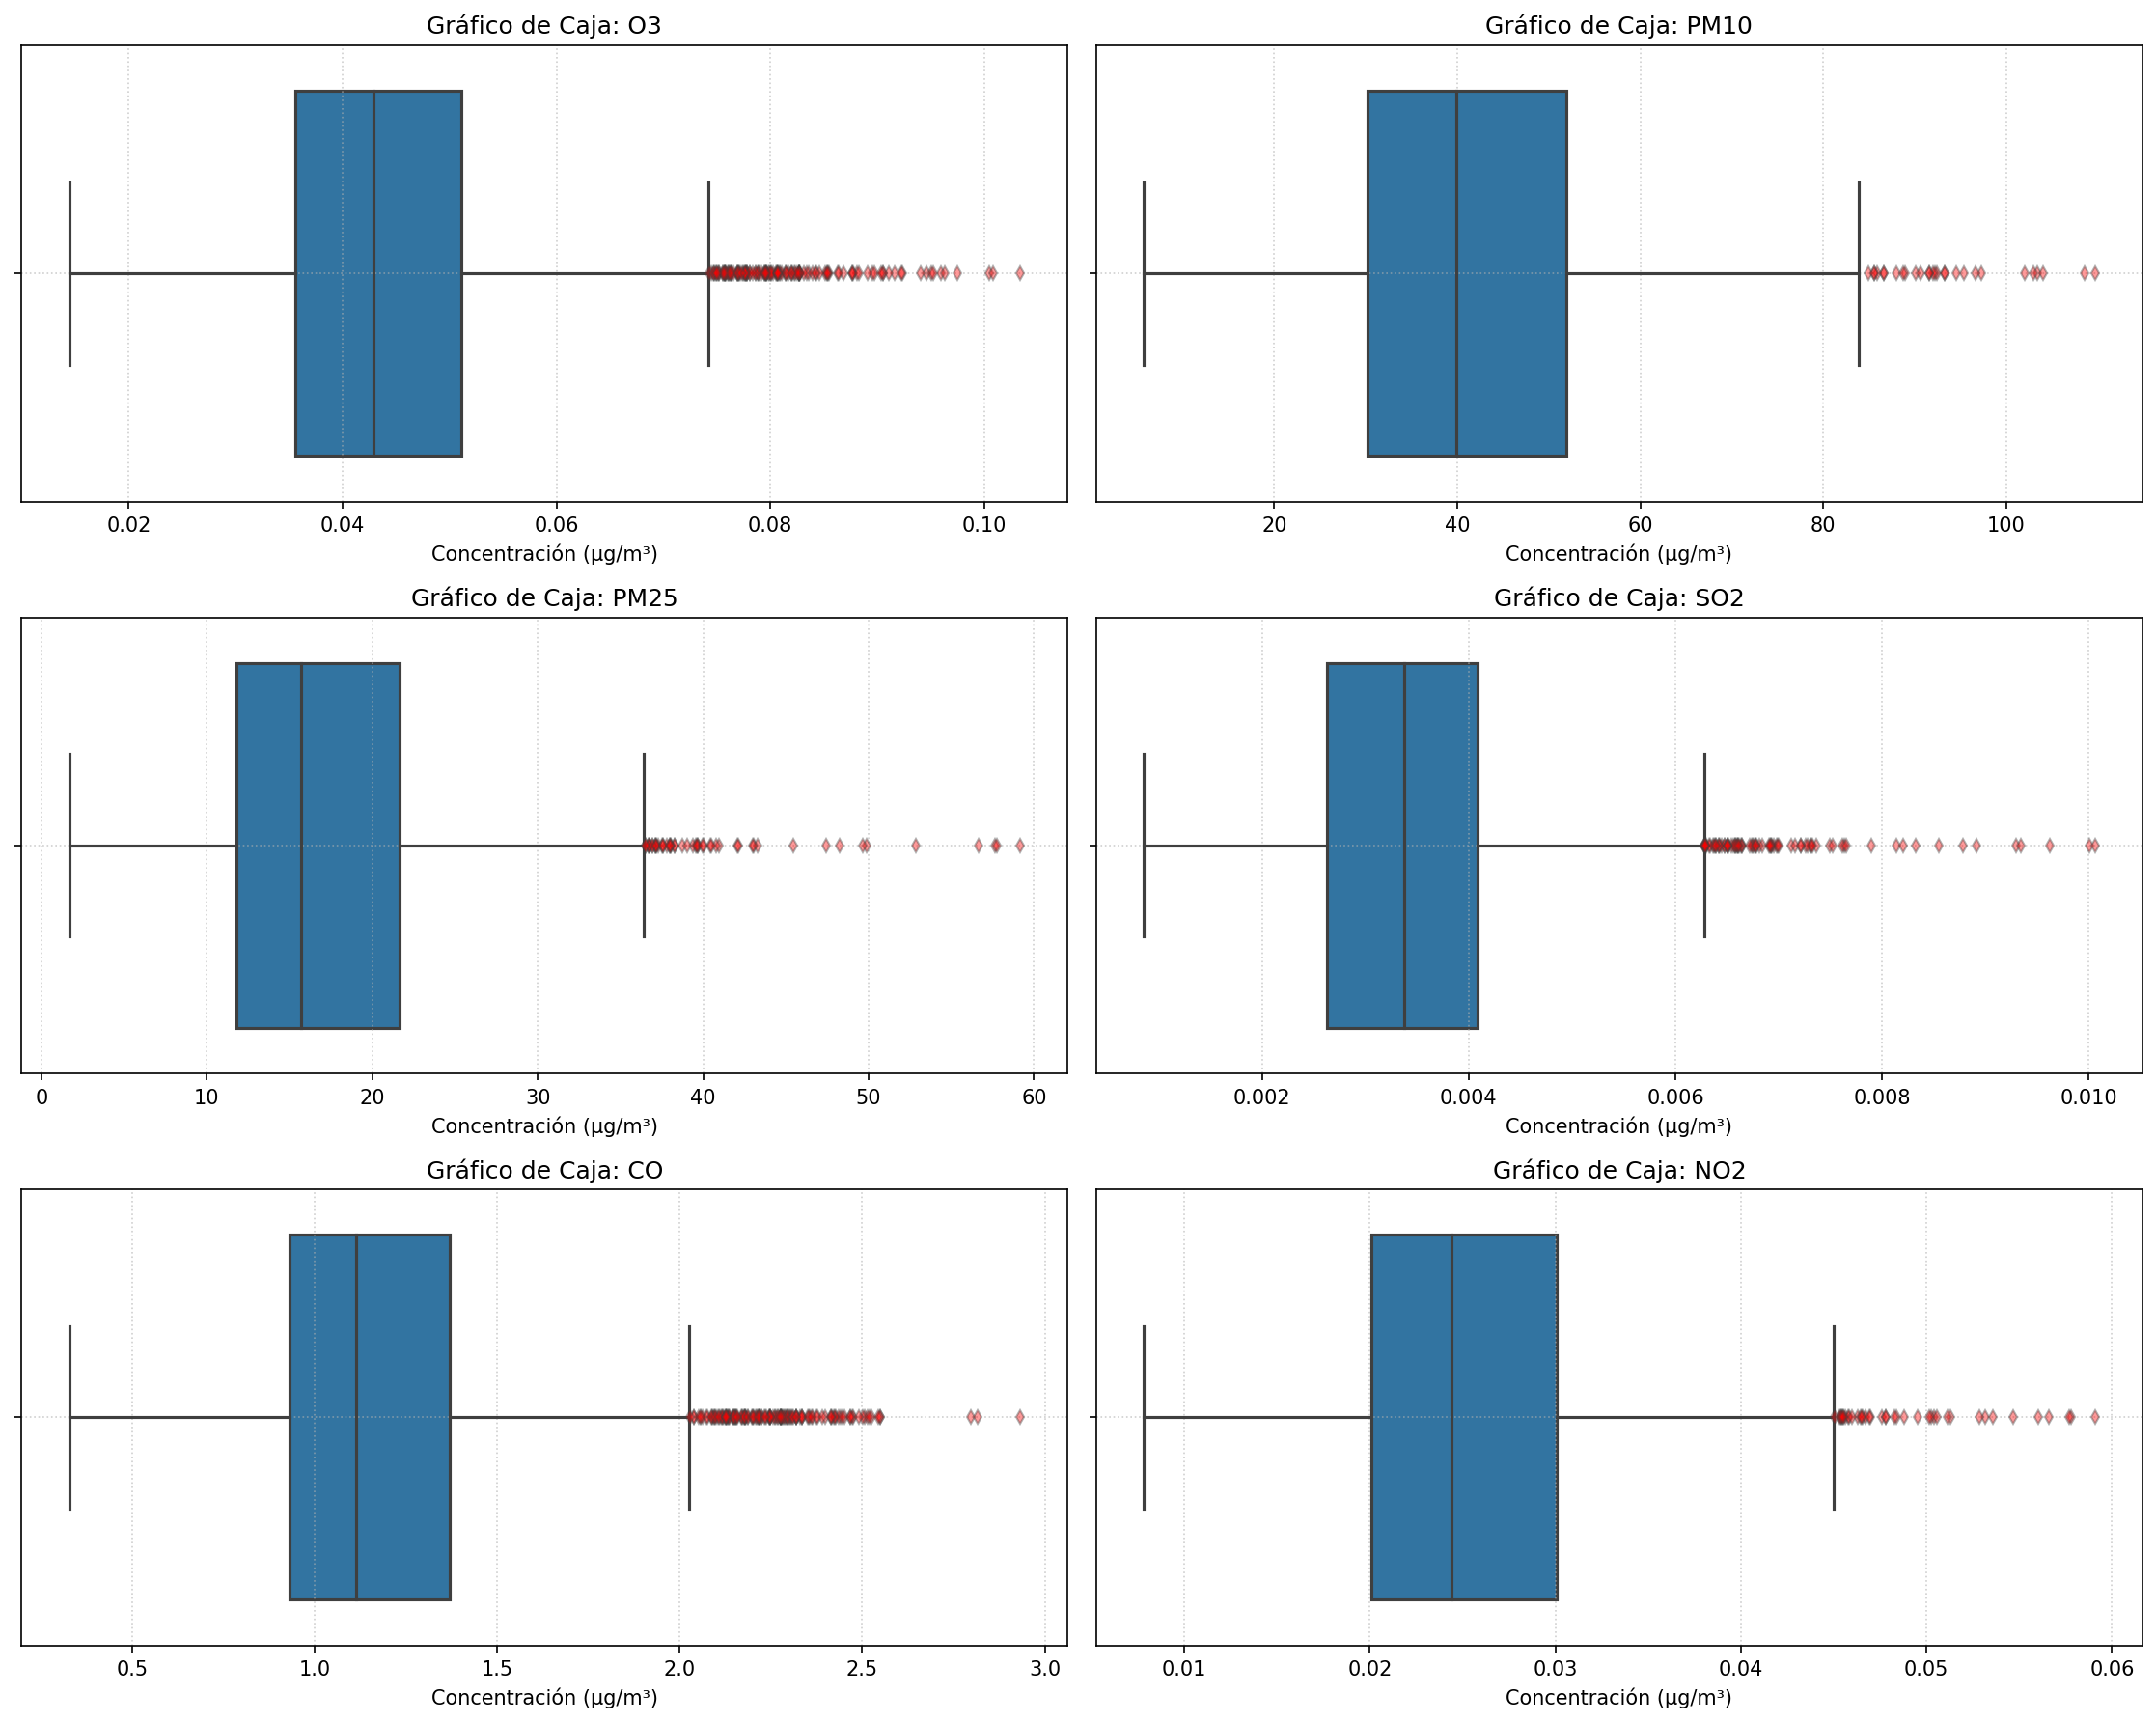

In [141]:
#Hacemos el gráfico  de cajas
#Configuramos la cuadrícula 
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12), dpi=150)
axes = axes.flatten() #convierte la tabla en una lista simple
#hacemos un for para enumerar el compuesto y hacemos de manera individual 
for i, comp in enumerate(contaminantes):
    sns.boxplot(x=contam_pue[comp], ax=axes[i], flierprops={'markerfacecolor':'red', 'alpha':0.4})
    axes[i].set_title(f'Gráfico de Caja: {comp}') # axes:indica el compuesto y el espacio que le toca
    axes[i].set_xlabel('Concentración (µg/m³)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [140]:
#obtenemos los datos atipicos con un for
contaminantes=['O3', 'PM10', 'PM25', 'SO2', 'CO', 'NO2']
for comp in contaminantes:
    Q1 = contam_pue[comp].quantile(0.25) # primer cuartil(25)
    Q3 = contam_pue[comp].quantile(0.75) # tercer cuartil(75)
    IQR = Q3 - Q1                        # rango intercuartílico
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
# Contamos los datos que caen fuera de los límites 
    num_atipicos = contam_pue[(contam_pue[comp] < limite_inferior) | (contam_pue[comp] > limite_superior)].shape[0]
    print(f"• {comp}: {num_atipicos} datos atípicos.")

• O3: 136 datos atípicos.
• PM10: 28 datos atípicos.
• PM25: 51 datos atípicos.
• SO2: 82 datos atípicos.
• CO: 145 datos atípicos.
• NO2: 41 datos atípicos.


b) Realice una prueba de contraste de normalidad para los datos. Obtenga una matriz de correlación y un mapa de calor de los contaminantes utilizando el coeficiente de correlación apropiado.


In [ ]:
from scipy.stats import shapiro #Usamos shapiro para la prueba de normalizacion

In [148]:
#HACEMOS PRUEBA DE CONTRASTE DE NORMALIDAD DE DATOS
contaminantes=['O3', 'PM10', 'PM25', 'SO2', 'CO', 'NO2']

for col in contaminantes:
    datos=contam_pue[col].dropna() #eliminamos los datos nulos 
    estadistico, p_value = stats.shapiro(datos)
    print(f'{col}:  Estadístico = {estadistico:.3f}, p-value = {p_value:.10f}\n')

O3:  Estadístico = 0.948, p-value = 0.0000000000

PM10:  Estadístico = 0.978, p-value = 0.0000000000

PM25:  Estadístico = 0.947, p-value = 0.0000000000

SO2:  Estadístico = 0.952, p-value = 0.0000000000

CO:  Estadístico = 0.940, p-value = 0.0000000000

NO2:  Estadístico = 0.973, p-value = 0.0000000000



In [152]:
#HACEMOS MATRIX DE CORRELACIÓN 
corr_conta=contam_pue.corr(method='spearman')
corr_conta

,O3,PM10,PM25,SO2,CO,NO2
O3,1.000000,0.153624,0.222908,0.181364,-0.140142,0.152639
PM10,0.153624,1.000000,0.801181,0.184809,0.077875,0.295981
PM25,0.222908,0.801181,1.000000,0.144050,-0.010204,0.315743
SO2,0.181364,0.184809,0.144050,1.000000,0.133664,0.340807
CO,-0.140142,0.077875,-0.010204,0.133664,1.000000,-0.007370
NO2,0.152639,0.295981,0.315743,0.340807,-0.007370,1.000000


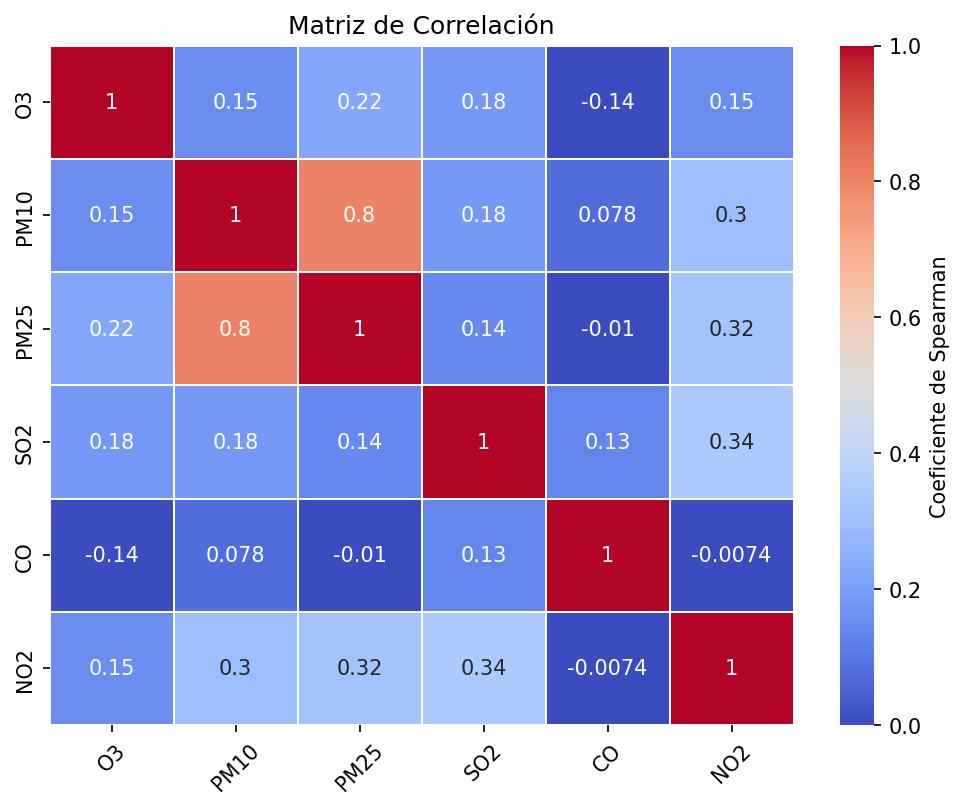

In [154]:
# HACEMOS MAPA DE CALOR
plt.figure(figsize=(8, 6),dpi=150)
sns.heatmap(corr_conta, annot=True,    
            cmap='coolwarm',    
            linewidths=0.2,
            cbar_kws={'label': 'Coeficiente de Spearman'},
           vmin = 0, vmax = 1, center = 0.5)
plt.title('Matriz de Correlación', fontsize=12)
plt.xticks(rotation=45)
plt.show()

c) Obtenga un DataFrame que muestre la correlación 2 a 2 entre los contaminantes. Grafique 3 diagramas de dispersión** entre los contaminantes que presentan mayor correlación, ya sea positiva o negativa.

Guiandonos del mapa de calor, obervamos que los 3 valores mas altos, es decir, lo que mas se acercan a 1 y -1 (ignorando la diagonal) son las parejas:
0.80 = PM10 Y PM25
0.34 = S02 Y NO2
0.32 = PM25 Y NO2
En base a eso, podemos formas las parejas

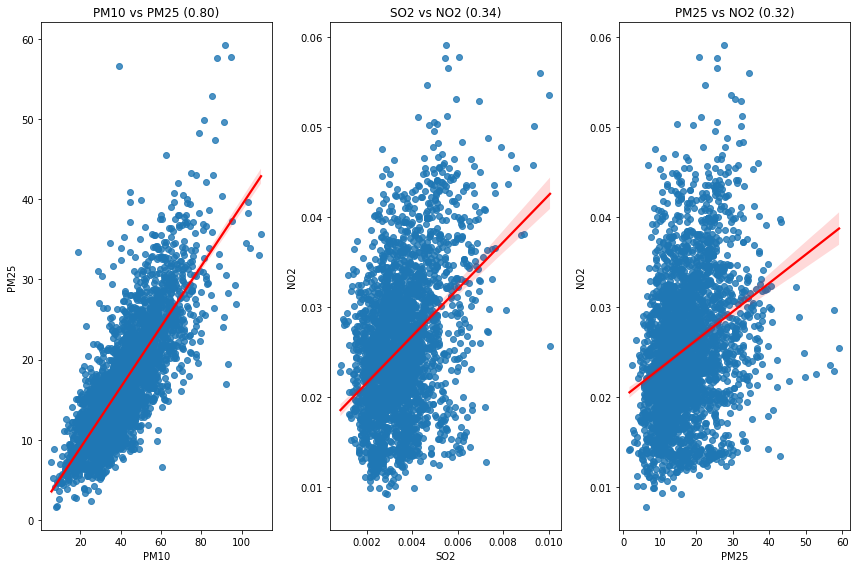

In [161]:
#Gráfico 1: PM10 vs PM25 (Correlación: 0.80)
plt.figure(figsize=(12,8))
plt.subplot(1, 3, 1) #indica donde la fila, columna y su espacio
sns.regplot(data=contam_pue, x="PM10", y="PM25", line_kws={"color": "red"})
plt.title("PM10 vs PM25 (0.80)")

#Gráfico 2: SO2 vs NO2 (Correlación: 0.34)
plt.subplot(1, 3, 2)
sns.regplot(data=contam_pue, x="SO2", y="NO2", line_kws={"color": "red"})
plt.title("SO2 vs NO2 (0.34)")

#Gráfico 3: PM25 vs NO2 (Correlación: 0.32)
plt.subplot(1, 3, 3)
sns.regplot(data=contam_pue, x="PM25", y="NO2", line_kws={"color": "red"})
plt.title("PM25 vs NO2 (0.32)")

plt.tight_layout()
plt.show()

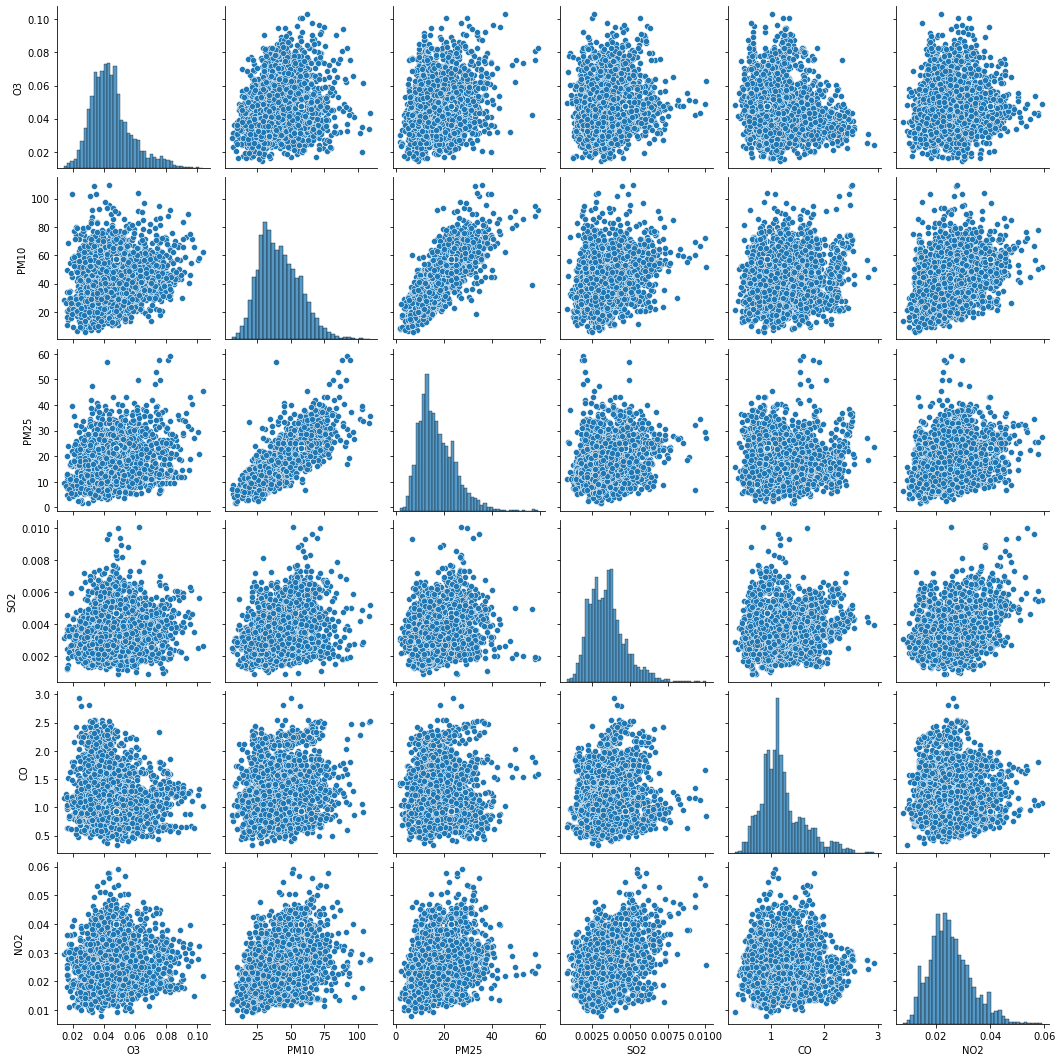

In [207]:
#Anexe esta parte para observar cómo se veían los demás compuestos
sns.pairplot(contam_pue)
plt.show()

d) Aplique el test de Mann-Kendall a todos los contaminantes y obtenga una gráfica con la línea de tendencia de cada uno (en caso de que exista).


In [165]:
contam_pue.columns

Index(['O3', 'PM10', 'PM25', 'SO2', 'CO', 'NO2'], dtype='object')

In [167]:
for val in contam_pue.columns:
    resultado = mk.original_test(contam_pue[val], alpha = 0.05)
    print(val)
    for val_1 in resultado: print(val_1)
    print('\n')

O3
increasing
True
0.0
17.591507915746828
0.21272110488218074
984559.0
3132394657.6666665
4.097957091780723e-06
0.036618215678404814


PM10
decreasing
True
6.661338147750939e-15
-7.7914418728468355
-0.09421629879679881
-436071.0
3132396641.6666665
-0.0025048446024340293
43.740424195857706


PM25
decreasing
True
0.01117620157945054
-2.537140732486618
-0.030679912704230813
-141999.0
3132386471.0
-0.0003692726766993715
16.254296591501287


SO2
increasing
True
0.0
15.533965649282166
0.18784081680009282
869403.0
3132395482.3333335
3.6216698450634786e-07
0.0028233345947905448


CO
decreasing
True
0.0
-18.73453024620918
-0.22653321242769914
-1048487.0
3132129109.6666665
-0.00013034442788541125
1.3123647582381186


NO2
increasing
True
0.0
17.235795094562977
0.208419621195475
964650.0
3132391177.3333335
2.8175689112537964e-06
0.020120591073960775




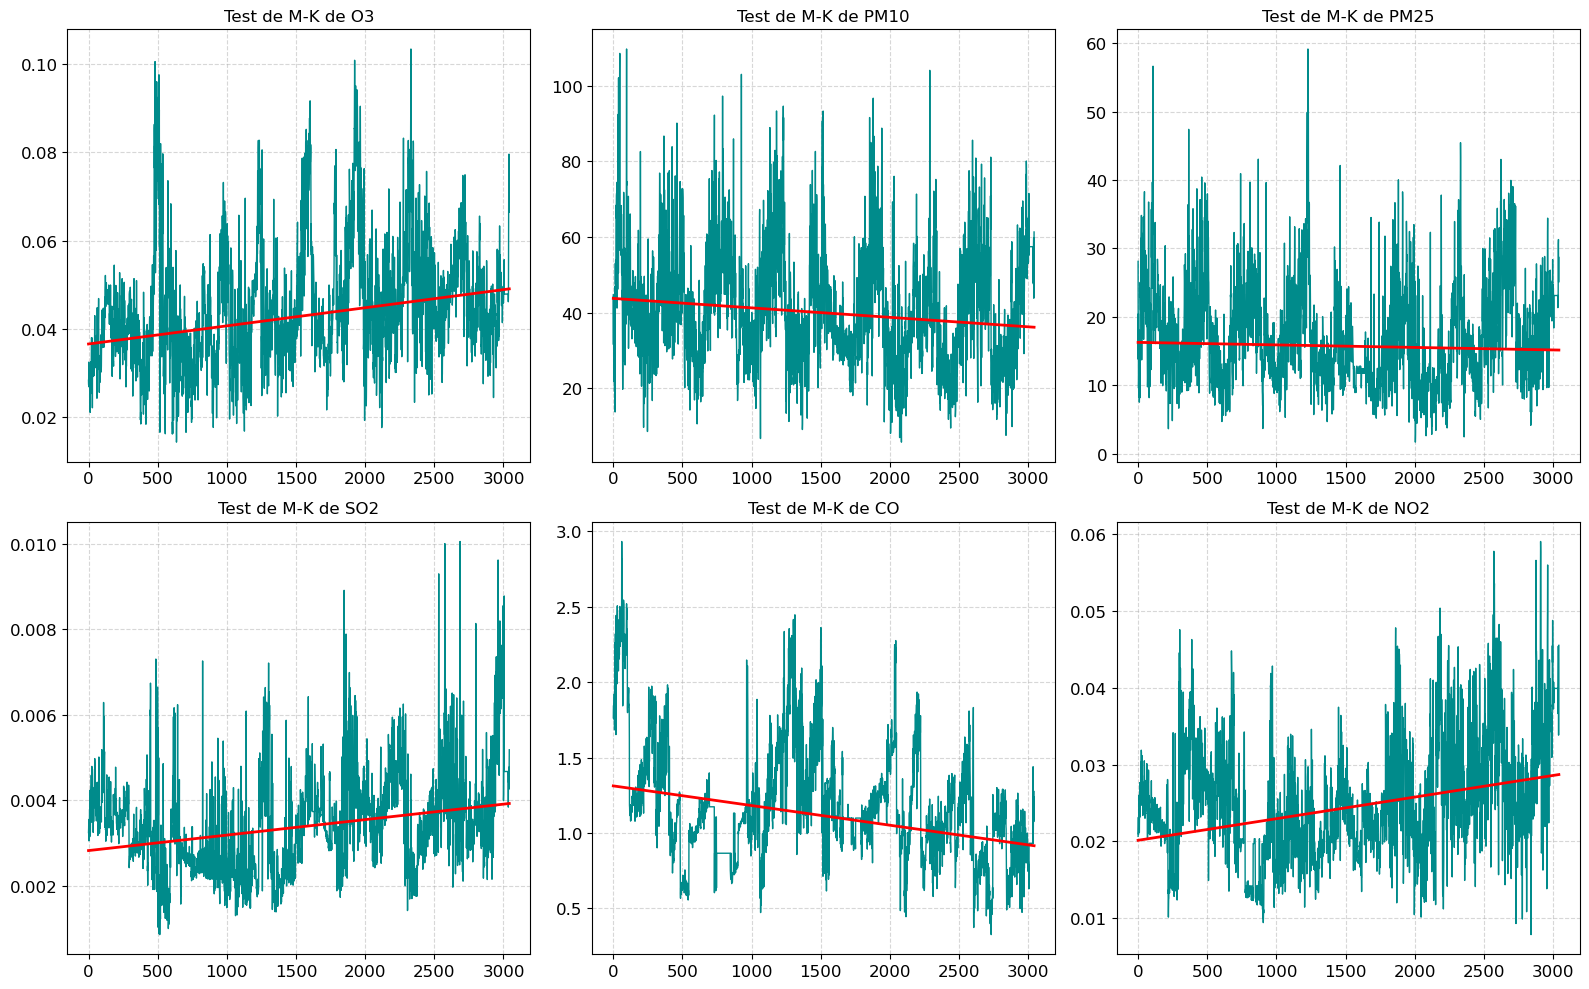

In [198]:
contaminantes = ["O3", "PM10", "PM25", "SO2", "CO", "NO2"]
plt.figure(figsize=(16, 10), dpi=100)

for idx, val in enumerate(contaminantes, 1): #hace un ciclo donde da el número de posición y el nomnre del contaminante
    datos_limpios = contam_pue[val].dropna().values #extrae los datos, limpiadolos, sin reglones vacíos 
    total_puntos = len(datos_limpios)
    resultado = mk.original_test(datos_limpios, alpha=0.05)
    slope = resultado.slope
    intercept = resultado.intercept
    linea_tendencia = []
# Construimos la línea de tendencia
    for i in range(0, total_puntos):
            linea_tendencia.append(slope * i + intercept)
# Graficamos la línea de tendencia directamente como una lista
    plt.subplot(2,3,idx)
    plt.plot(datos_limpios,color= "darkcyan",linewidth=1)
    plt.plot(linea_tendencia, color="red", linewidth=2)
    plt.title(f"Test de M-K de {val}")
    plt.tick_params(labelsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

CUANDO TENEMOS DATOS CON MUCHO RUIDO (PICOS) ES COMPLICADO OBSERVAR TU TENDENCIA, LA LÍNEA ROJA NOS DICE SU PENDIENTE, SI ESTA ES POSITIVA: EL CONTAMINANTE AUMENTA A ALRGO PLAZO, PERO SI ES NEGATIVA NOS DICE QUE ESTA DISMINUYENDO A LARGO PLAZO. LOS CONTAMINANTES QUE MAS INCREMENTARON SON O3, NO2. 

e) Compruebe la existencia de tendencia mediante el método ITA (Innovative Trend Analysis).

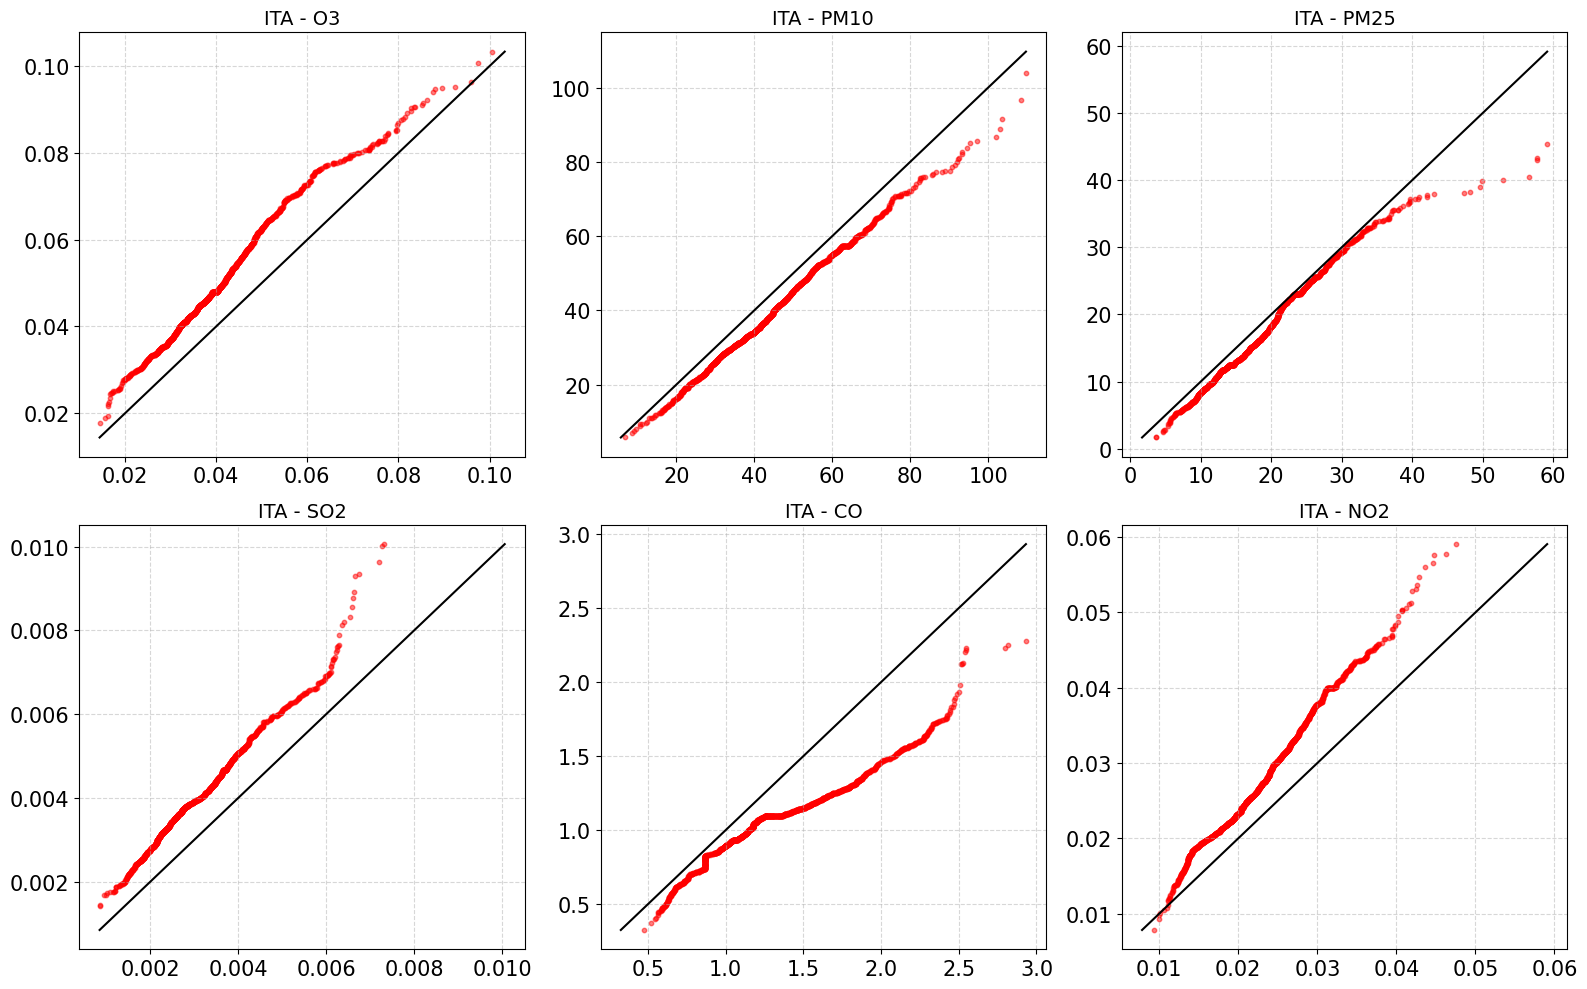

In [201]:
plt.figure(figsize=(16,10 ), dpi=100)

for idx, val in enumerate(contaminantes, 1):
    df_limpio = contam_pue[val].dropna()
    mitad = int(len(df_limpio) / 2)
    p1 = df_limpio.iloc[0:mitad]
    p2 = df_limpio.iloc[mitad : 2 * mitad]
    plt.subplot(2, 3, idx)
    plt.scatter(sorted(p1), sorted(p2), s=10, color="red", alpha=0.5)
    plt.tick_params(labelsize=15)
    x_min = float(df_limpio.min()) #da valores de cada contaminante, los pone a escala (debido a las variaciones)
    x_max = float(df_limpio.max())
    x_vals = np.linspace(x_min, x_max, 100)
    
    plt.plot(x_vals, x_vals, color="black")
    #Agregamos infromacion de cada gráfico 
    plt.title(f"ITA - {val}", fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

NOTAMO QUE LOS PUNTOS QUE QUEDAN ENCIMA DE LA DIAGONAL TIENEN SEÑAL DE TENDENCIA CRECIENTE Y LOS QUE ESTAN POR DEBAJO SON DECRECIENTES Y LOS PUNTOS QUE ESTAN DISPERSOS NO TIENEN TENDENCIA.  